In [ ]:
import pandas as pd

def plan1_constante(demanda, dias_mes, costos, empleados, produccion_diaria):
    
    resultados = []
    inventario = 0
    inventario_total = 0

    meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"]

    for mes_nombre, d, dias in zip(meses, demanda, dias_mes):
        produccion_mes = produccion_diaria * dias
        valoracion = produccion_mes - d
        inventario = inventario + valoracion
        inventario_total += max(0, inventario)

        valoracion_str = f"+{valoracion}" if valoracion >= 0 else f"{valoracion}"

        resultados.append({
            "Mes": mes_nombre,
            f"Producción a {produccion_diaria} unidades/día": f"{produccion_mes:,}".replace(",", "."),
            "Demanda estimada": f"{d:,}".replace(",", "."),
            "Valoración mensual del inventario": valoracion_str,
            "Inventario final": inventario,
        })

    df = pd.DataFrame(resultados)
    fila_total = pd.DataFrame([{
        "Mes": "Total",
        f"Producción a {produccion_diaria} unidades/día": "",
        "Demanda estimada": "",
        "Valoración mensual del inventario": "",
        "Inventario final": f"{inventario_total:,}".replace(",", "."),
    }])
    df_final = pd.concat([df, fila_total], ignore_index=True)

    # ==========================================
    # FUNCIONES INTERNAS: PRODUCCIÓN PROPIA Y SUBCONTRATACIÓN
    # ==========================================
    def produccion_propia(unidades_por_dia, dias_totales): # funcion de produccion realizada 
        return unidades_por_dia * dias_totales

    def unidades_subcontratadas(demanda_total, produccion_propia_valor):# unidades subcontratadas
        return max(0, demanda_total - produccion_propia_valor)

    # Cálculos
    demanda_total = sum(demanda)
    dias_totales = sum(dias_mes)
    prod_propia = produccion_propia(produccion_diaria, dias_totales)
    subcontratadas = unidades_subcontratadas(demanda_total, prod_propia)

    # ==========================================
    # TABLA DE COSTES
    # ==========================================
    coste_inventario = inventario_total * costos["inventario"]
    coste_mano_obra = empleados * costos["salario"] * dias_totales
    coste_subcontratacion = subcontratadas * costos.get("subcontratacion", 0)
    coste_total = coste_inventario + coste_mano_obra + coste_subcontratacion

    tabla_costes = pd.DataFrame([
        {"Costes": f"Inventario {coste_inventario}$", "Cálculos": f"(= {inventario_total} unidades almacenadas x {costos['inventario']}$/unidad)"},
        {"Costes": f"Mano de obra en periodo regular {coste_mano_obra}$", "Cálculos": f"(= {empleados} empleados x {costos['salario']}$/día x {dias_totales} días)"},
        {"Costes": f"Subcontratación {coste_subcontratacion}$", "Cálculos": f"(= {subcontratadas} unidades subcontratadas x {costos.get('subcontratacion',0)}$/unidad)"},
        {"Costes": f"Coste total {coste_total}$", "Cálculos": ""},
    ])

    return df_final, tabla_costes


In [26]:
demanda_imagen = [900, 700, 800, 1200, 1500, 1100]
dias_mes_imagen = [22, 18, 21, 21, 22, 20]
costos = {"inventario": 5, "salario": 40, "subcontratacion": 10} # COSTOS DE CONTRATACION 


df_produccion, df_costes = plan1_constante(demanda_imagen, dias_mes_imagen, costos=costos, empleados =6, produccion_diaria =30)

print("\n=== TABLA DE PRODUCCIÓN VS DEMANDA ===")
print(df_produccion.to_string(index=False))

print("\n=== TABLA DE COSTES ===")
print(df_costes.to_string(index=False))



=== TABLA DE PRODUCCIÓN VS DEMANDA ===
    Mes Producción a 30 unidades/día Demanda estimada Valoración mensual del inventario Inventario final
  Enero                          660              900                              -240             -240
Febrero                          540              700                              -160             -400
  Marzo                          630              800                              -170             -570
  Abril                          630            1.200                              -570            -1140
   Mayo                          660            1.500                              -840            -1980
  Junio                          600            1.100                              -500            -2480
  Total                                                                                                0

=== TABLA DE COSTES ===
                                Costes                                      Cálculos
          

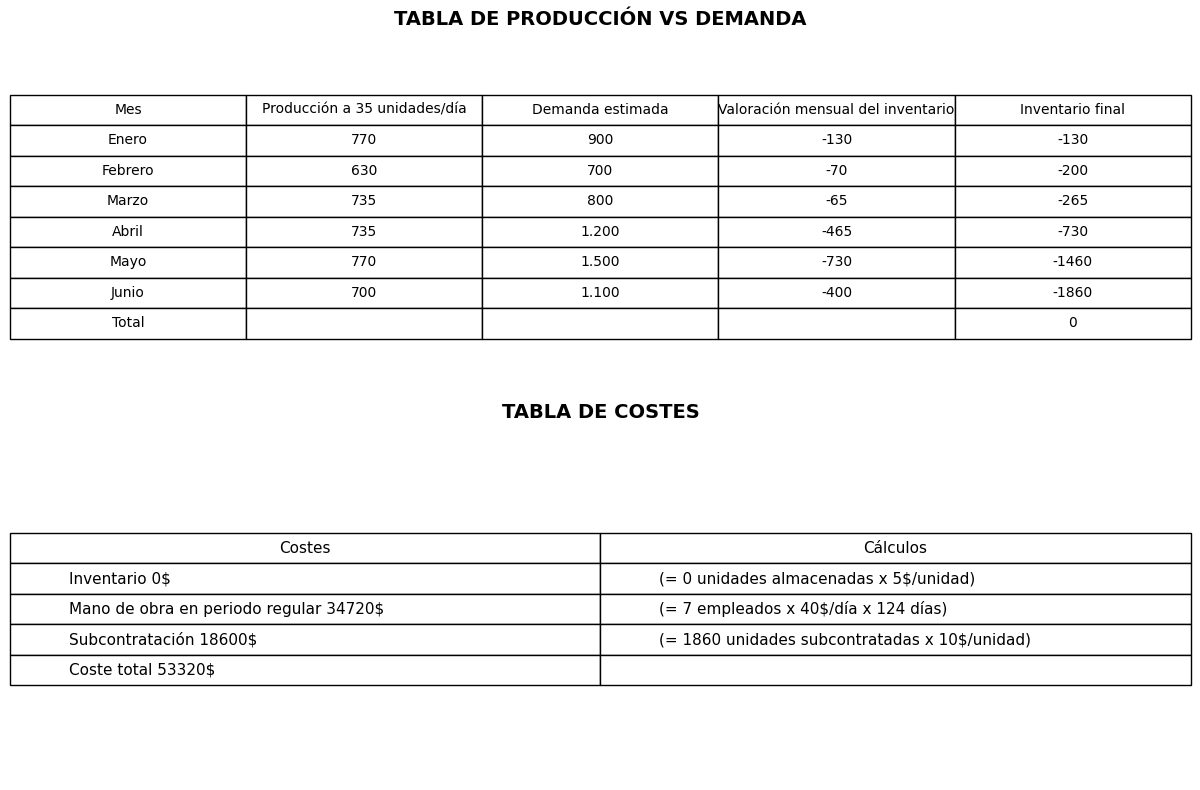

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# CELDA DE INPUTS
# ==========================
demanda_imagen = [900, 700, 800, 1200, 1500, 1100]
dias_mes_imagen = [22, 18, 21, 21, 22, 20]
costos = {"inventario": 5, "salario": 40, "subcontratacion": 10}  # Costos
empleados = 7              #CAMBIAR CHANGOS
produccion_diaria = 35        # CAMBIA SEGUN CANTIDAD DE CHANGOS

# ==========================
# FUNCIÓN PRINCIPAL
# ==========================
def plan1_constante(demanda, dias_mes, costos, empleados, produccion_diaria):
    resultados = []
    inventario = 0
    inventario_total = 0
    meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"]

    for mes_nombre, d, dias in zip(meses, demanda, dias_mes):
        produccion_mes = produccion_diaria * dias
        valoracion = produccion_mes - d
        inventario = inventario + valoracion
        inventario_total += max(0, inventario)

        valoracion_str = f"+{valoracion}" if valoracion >= 0 else f"{valoracion}"

        resultados.append({
            "Mes": mes_nombre,
            f"Producción a {produccion_diaria} unidades/día": f"{produccion_mes:,}".replace(",", "."),
            "Demanda estimada": f"{d:,}".replace(",", "."),
            "Valoración mensual del inventario": valoracion_str,
            "Inventario final": inventario,
        })

    df = pd.DataFrame(resultados)
    fila_total = pd.DataFrame([{
        "Mes": "Total",
        f"Producción a {produccion_diaria} unidades/día": "",
        "Demanda estimada": "",
        "Valoración mensual del inventario": "",
        "Inventario final": f"{inventario_total:,}".replace(",", "."),
    }])
    df_final = pd.concat([df, fila_total], ignore_index=True)

    # Funciones internas
    def produccion_propia(unidades_por_dia, dias_totales):
        return unidades_por_dia * dias_totales

    def unidades_subcontratadas(demanda_total, produccion_propia_valor):
        return max(0, demanda_total - produccion_propia_valor)

    # Cálculos
    demanda_total = sum(demanda)
    dias_totales = sum(dias_mes)
    prod_propia = produccion_propia(produccion_diaria, dias_totales)
    subcontratadas = unidades_subcontratadas(demanda_total, prod_propia)

    # Tabla de costes
    coste_inventario = inventario_total * costos["inventario"]
    coste_mano_obra = empleados * costos["salario"] * dias_totales
    coste_subcontratacion = subcontratadas * costos.get("subcontratacion", 0)
    coste_total = coste_inventario + coste_mano_obra + coste_subcontratacion

    tabla_costes = pd.DataFrame([
        {"Costes": f"Inventario {coste_inventario}$", "Cálculos": f"(= {inventario_total} unidades almacenadas x {costos['inventario']}$/unidad)"},
        {"Costes": f"Mano de obra en periodo regular {coste_mano_obra}$", "Cálculos": f"(= {empleados} empleados x {costos['salario']}$/día x {dias_totales} días)"},
        {"Costes": f"Subcontratación {coste_subcontratacion}$", "Cálculos": f"(= {subcontratadas} unidades subcontratadas x {costos.get('subcontratacion',0)}$/unidad)"},
        {"Costes": f"Coste total {coste_total}$", "Cálculos": ""},
    ])

    return df_final, tabla_costes

# ==========================
# EJECUCIÓN
# ==========================
df_produccion, df_costes = plan1_constante(
    demanda_imagen, dias_mes_imagen, costos=costos, empleados=empleados, produccion_diaria=produccion_diaria
)

# ==========================
# EXPORTAR TABLAS COMO IMAGEN
# ==========================
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.patch.set_facecolor('white')

# Tabla Producción vs Demanda
axes[0].axis('off')
tabla1 = axes[0].table(cellText=df_produccion.values,
                       colLabels=df_produccion.columns,
                       cellLoc='center', loc='center')
tabla1.auto_set_font_size(False)
tabla1.set_fontsize(10)
tabla1.scale(1.2, 1.5)
axes[0].set_title("TABLA DE PRODUCCIÓN VS DEMANDA", fontsize=14, fontweight='bold', color='black', pad=15)

# Tabla Costes
axes[1].axis('off')
tabla2 = axes[1].table(cellText=df_costes.values,
                       colLabels=df_costes.columns,
                       cellLoc='left', loc='center')
tabla2.auto_set_font_size(False)
tabla2.set_fontsize(11)
tabla2.scale(1.2, 1.5)
axes[1].set_title("TABLA DE COSTES", fontsize=14, fontweight='bold', color='black', pad=15)

# Estilo general
for ax in axes:
    for key, cell in ax.tables[0].get_celld().items():
        cell.set_edgecolor('black')
        cell.set_facecolor('white')
        cell.get_text().set_color('black')

plt.tight_layout()
plt.savefig("tablas_plan1.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


#### seguimiento a la caza 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# CELDA DE INPUTS
# ==========================
demanda_imagen = [1400, 1600, 1800, 2200, 2200, 1400]
dias_mes_imagen = [22, 18, 21, 21, 22, 20]
costos = {"inventario": 200, "salario": 40, "subcontratacion": 10}  # Costos
empleados = 7              #CAMBIAR CHANGOS
produccion_diaria = 35        # CAMBIA SEGUN CANTIDAD DE CHANGOS

# ==========================
# FUNCIÓN PRINCIPAL
# ==========================
def plan1_constante(demanda, dias_mes, costos, empleados, produccion_diaria):
    resultados = []
    inventario = 0
    inventario_total = 0
    meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto"]

    for mes_nombre, d, dias in zip(meses, demanda, dias_mes):
        produccion_mes = produccion_diaria * dias
        valoracion = produccion_mes - d
        inventario = inventario + valoracion
        inventario_total += max(0, inventario)

        valoracion_str = f"+{valoracion}" if valoracion >= 0 else f"{valoracion}"

        resultados.append({
            "Mes": mes_nombre,
            f"Producción a {produccion_diaria} unidades/día": f"{produccion_mes:,}".replace(",", "."),
            "Demanda estimada": f"{d:,}".replace(",", "."),
            "Valoración mensual del inventario": valoracion_str,
            "Inventario final": inventario,
        })

    df = pd.DataFrame(resultados)
    fila_total = pd.DataFrame([{
        "Mes": "Total",
        f"Producción a {produccion_diaria} unidades/día": "",
        "Demanda estimada": "",
        "Valoración mensual del inventario": "",
        "Inventario final": f"{inventario_total:,}".replace(",", "."),
    }])
    df_final = pd.concat([df, fila_total], ignore_index=True)

    # Funciones internas
    def produccion_propia(unidades_por_dia, dias_totales):
        return unidades_por_dia * dias_totales

    def unidades_subcontratadas(demanda_total, produccion_propia_valor):
        return max(0, demanda_total - produccion_propia_valor)

    # Cálculos
    demanda_total = sum(demanda)
    dias_totales = sum(dias_mes)
    prod_propia = produccion_propia(produccion_diaria, dias_totales)
    subcontratadas = unidades_subcontratadas(demanda_total, prod_propia)

    # Tabla de costes
    coste_inventario = inventario_total * costos["inventario"]
    coste_mano_obra = empleados * costos["salario"] * dias_totales
    coste_subcontratacion = subcontratadas * costos.get("subcontratacion", 0)
    coste_total = coste_inventario + coste_mano_obra + coste_subcontratacion

    tabla_costes = pd.DataFrame([
        {"Costes": f"Inventario {coste_inventario}$", "Cálculos": f"(= {inventario_total} unidades almacenadas x {costos['inventario']}$/unidad)"},
        {"Costes": f"Mano de obra en periodo regular {coste_mano_obra}$", "Cálculos": f"(= {empleados} empleados x {costos['salario']}$/día x {dias_totales} días)"},
        {"Costes": f"Subcontratación {coste_subcontratacion}$", "Cálculos": f"(= {subcontratadas} unidades subcontratadas x {costos.get('subcontratacion',0)}$/unidad)"},
        {"Costes": f"Coste total {coste_total}$", "Cálculos": ""},
    ])

    return df_final, tabla_costes

# ==========================
# EJECUCIÓN
# ==========================
df_produccion, df_costes = plan1_constante(
    demanda_imagen, dias_mes_imagen, costos=costos, empleados=empleados, produccion_diaria=produccion_diaria
)

# ==========================
# EXPORTAR TABLAS COMO IMAGEN
# ==========================
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.patch.set_facecolor('white')

# Tabla Producción vs Demanda
axes[0].axis('off')
tabla1 = axes[0].table(cellText=df_produccion.values,
                       colLabels=df_produccion.columns,
                       cellLoc='center', loc='center')
tabla1.auto_set_font_size(False)
tabla1.set_fontsize(10)
tabla1.scale(1.2, 1.5)
axes[0].set_title("TABLA DE PRODUCCIÓN VS DEMANDA", fontsize=14, fontweight='bold', color='black', pad=15)

# Tabla Costes
axes[1].axis('off')
tabla2 = axes[1].table(cellText=df_costes.values,
                       colLabels=df_costes.columns,
                       cellLoc='left', loc='center')
tabla2.auto_set_font_size(False)
tabla2.set_fontsize(11)
tabla2.scale(1.2, 1.5)
axes[1].set_title("TABLA DE COSTES", fontsize=14, fontweight='bold', color='black', pad=15)

# Estilo general
for ax in axes:
    for key, cell in ax.tables[0].get_celld().items():
        cell.set_edgecolor('black')
        cell.set_facecolor('white')
        cell.get_text().set_color('black')

plt.tight_layout()
plt.savefig("tablas_plan1.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
